In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("./s2_data.csv", encoding="utf-8-sig")
df.head()

,date,DIST,FI,MAC,ELS,MULT,mktrf,smb,hml,rmw,cma,rf
0,31/12/2000,235.70,156.56,241.52,283.25,191.90,1.19,3.26,7.61,1.71,4.79,0.50
1,31/01/2001,242.51,158.79,249.53,281.60,195.04,3.13,5.48,-5.07,-4.69,-5.03,0.54
2,28/02/2001,247.16,159.63,252.00,274.79,195.51,-10.05,2.83,12.47,9.10,9.07,0.38
3,31/03/2001,250.56,160.02,258.90,269.47,195.69,-7.26,2.33,6.42,3.35,3.92,0.42
4,30/04/2001,253.05,162.13,260.69,271.55,198.21,7.94,-0.86,-4.67,-3.06,-3.20,0.39


In [3]:
from homework02 import clean_data

In [4]:
df = clean_data(df)
df.head()

,date,DIST,FI,MAC,ELS,MULT,mktrf,smb,hml,rmw,cma,rf
0,2000-12-31,235.70,156.56,241.52,283.25,191.90,1.19,3.26,7.61,1.71,4.79,0.50
1,2001-01-31,242.51,158.79,249.53,281.60,195.04,3.13,5.48,-5.07,-4.69,-5.03,0.54
2,2001-02-28,247.16,159.63,252.00,274.79,195.51,-10.05,2.83,12.47,9.10,9.07,0.38
3,2001-03-31,250.56,160.02,258.90,269.47,195.69,-7.26,2.33,6.42,3.35,3.92,0.42
4,2001-04-30,253.05,162.13,260.69,271.55,198.21,7.94,-0.86,-4.67,-3.06,-3.20,0.39


In [5]:
df.iloc[0]

date     2000-12-31 00:00:00
DIST                   235.7
FI                    156.56
MAC                   241.52
ELS                   283.25
MULT                   191.9
mktrf                   1.19
smb                     3.26
hml                     7.61
rmw                     1.71
cma                     4.79
rf                       0.5
Name: 0, dtype: object

## Ex. 1

In [6]:
from homework02 import prepare_data

In [7]:
df = prepare_data(df)

In [8]:
from homework02 import estimate_market_model

In [9]:
model = estimate_market_model(df)
alpha = model.params["const"]
beta = model.params["mktrf"]

print("alpha:", alpha)
print("beta:", beta)
print("R^2:", model.rsquared)
print("alpha p-value:", model.pvalues["const"])
print("SE(alpha):", model.bse["const"])
print("SE(beta):", model.bse["mktrf"])

alpha: 0.28503307512052894
beta: 0.17390168454626595
R^2: 0.31924747957869903
alpha p-value: 7.072417615957508e-05
SE(alpha): 0.07063443764563454
SE(beta): 0.01531328383622872


In [10]:
if model.pvalues["const"] <= 0.05: 
    print("REJECT H_0, where H_0: alpha = 0")
else: 
    print("DO NOT (!) REJECT H_0, where H_0: alpha = 0")

REJECT H_0, where H_0: alpha = 0


### Interpretation Ex. 1
Since the p-value is lower then the significance level, we reject H_0 and therefore alpha is not statistically significant.

## Ex. 2

In [11]:
from homework02 import plot_residuals, test_heterodkedasticity

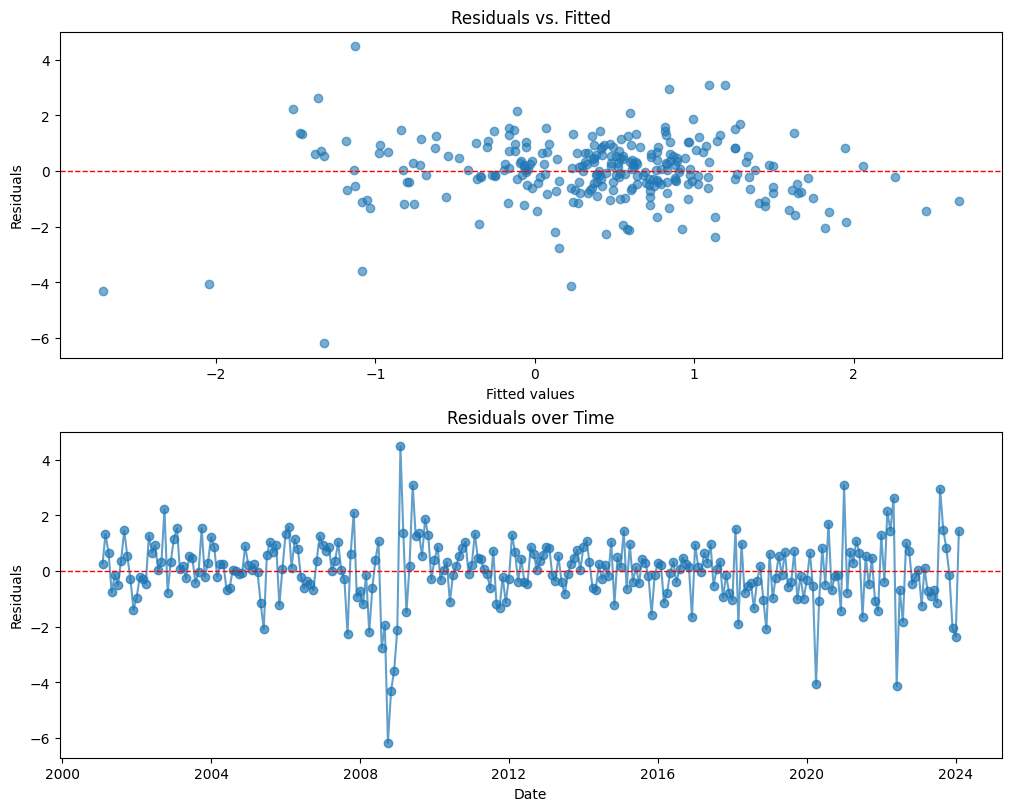

In [12]:
plot_residuals(df, model)

In [13]:
stats = test_heterodkedasticity(df, model)

for key in stats.keys():
    print(f"{key}: {stats.get(key)}: ")

white_stat: 52.81401689772642: 
white_pvalue: 3.4008066961916355e-12: 
f_stat: 32.274632940310454: 
f_pvalue: 2.591970412858337e-13: 


### Interpretation Ex. 2
- The hypothesis i.e. H_0:= errors are homoskedasticity
- We used the White test to test for heteroskedasticity.
- the p-value (of the White test) is seen above (~3.401^{-12})

The residuals show clear time-varying volatility. The most pronounced high-volatility episode is during the financial crisis, roughly from September 2008 to mid-2009, where residuals fluctuate much more strongly than in the rest of the sample. A White test rejects homoskedasticity strongly (p-value near zero), so there is evidence of heteroskedasticity supported by the rejection of H_0 by the p-value.

## Ex. 3

In [14]:
from homework02 import exercise_3_autocorr_check

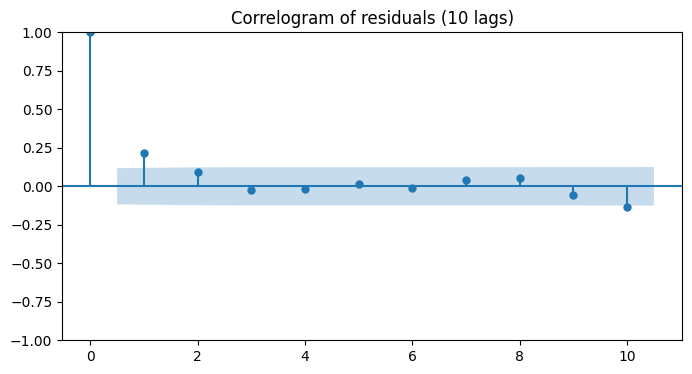

durbin_watson: 1.56433941282161: 
conclusion: evidence of negative first-order autocorrelation: 


In [15]:
results = exercise_3_autocorr_check(model)
for key in results.keys():
    print(f"{key}: {results.get(key)}: ")

### Comment on the plot: 
The *H_0* is defined as: *NO* first-order autocorrelation
The blue band is the confidence band defined by default at 95%: 
- if the stick is inside the confidence band: *DO NOT* reject H_0
- if the stick is outside the confidence band: *reject* H_0

### Comment on the Durbin-Watson test for first-order autocorrelation
- The lecture notes say that we reject if DW_Score < 1.5. Since we obtain a value of ~1.5643 we do *NOT* reject H_0 => Therefore, we do not find sufficient evidence of positive first-order autocorrelation. 

## Ex. 4

## Interpretation Ex. 4
No. The regression coefficients $\hat{\alpha}$ and $\hat{\beta}$ do **not** change when the errors are corrected for heteroskedasticity and autocorrelation, **as long as the estimator remains OLS**.

The reason is that the OLS point estimate is still

$$
\hat{\beta}_{\mathrm{OLS}} = (X'X)^{-1}X'y,
$$

so it depends only on the regressors and the dependent variable, not on the covariance correction.

What changes is the **estimated variance-covariance matrix** of the OLS estimator. Therefore, the **standard errors, t-statistics, p-values, and confidence intervals** may change, but not the coefficient estimates themselves.

In the lecture notes, heteroskedasticity is handled by **White’s covariance matrix** and autocorrelation by **Newey–West**, both as adjustments to the covariance matrix of the OLS estimator, not as changes to the OLS coefficients.    

## Ex. 5

In [16]:
from homework02 import exercise_5_hac_results

In [17]:
comparison, hac_model = exercise_5_hac_results(model, maxlags=1)
comparison.round(6)

,coef_OLS,se_OLS,t_OLS,p_OLS,coef_HAC,se_HAC,t_HAC,p_HAC
const,0.285033,0.070634,4.035327,0.000071,0.285033,0.088067,3.236560,0.001358
mktrf,0.173902,0.015313,11.356263,0.000000,0.173902,0.029491,5.896851,0.000000


### Interpretation Ex. 5
### Exercise 5 interpretation

Using **Newey–West HAC** standard errors does **not** change the OLS coefficient estimates: $\hat{\alpha} = 0.2850$ and $\hat{\beta} = 0.1739$ are unchanged. This is expected, because HAC corrects the **estimated variance-covariance matrix** of the OLS estimator, not the OLS point estimates themselves.

Compared with the usual OLS results, the **standard errors increase** noticeably. For $\hat{\alpha}$, the standard error rises from $0.0706$ to $0.0881$. For $\hat{\beta}$, it rises from $0.0153$ to $0.0295$.

As a consequence, the **t-statistics fall** and the **p-values increase**, so inference becomes more conservative. However, both coefficients remain statistically significant: $\hat{\alpha}$ is still significant at the 1% level with $p = 0.00136$, and $\hat{\beta}$ remains highly significant.

Therefore, correcting for heteroskedasticity and autocorrelation reduces the estimated precision of the coefficients, but it does **not** change the qualitative conclusion of the regression.

## Ex. 6

In [ ]:
from homework02 import exercise_6_sure_capm

In [ ]:
sur_model, resid_cov = exercise_6_sure_capm(df)
print(sur_model.summary)

In [ ]:
print("Residual covariance matrix:")
resid_cov.round(6)

### Interpretation Ex. 6
We estimate three CAPM equations (for MAC, MULT and ELS) jointly using **Seemingly Unrelated Regression (SUR)** with a non-HAC (unadjusted) covariance estimator.

SUR exploits the cross-equation correlation of residuals to produce more efficient estimates than running three separate OLS regressions. The residual covariance matrix above shows the pairwise covariances between the three equation residuals — the diagonal entries are the variances of each equation's residuals, and the off-diagonal entries capture how the residuals co-move across the three hedge fund strategies.

## Ex. 7

In [ ]:
from homework02 import exercise_7_joint_alpha_test

In [ ]:
results = exercise_7_joint_alpha_test(sur_model)
for key, val in results.items():
    print(f"{key}: {val}")

### Interpretation Ex. 7
We test $H_0: \alpha_{MAC} = \alpha_{MULT} = \alpha_{ELS} = 0$ using a **Wald $\chi^2$ test**.

- **Test statistic:** $\chi^2 \approx 26.88$
- **Critical value** ($\chi^2_3$ at 5%): $7.81$
- **Conclusion:** Since $26.88 > 7.81$, we **reject** $H_0$. The three alphas are jointly significant at the 5% level, meaning at least one of the hedge fund strategies generates a statistically significant abnormal return relative to the CAPM.

## Ex. 8

In [ ]:
from homework02 import exercise_8_post_crisis_beta_test

In [ ]:
results = exercise_8_post_crisis_beta_test(df, beta_null=0.21)
for key, val in results.items():
    if key != "hac_model":
        print(f"{key}: {val}")

### Interpretation Ex. 8
We subsample the data from **2009-07** onward (post-recession, 175 observations) and re-estimate the CAPM on MULT with **HAC standard errors**.

We then test $H_0: \beta = 0.21$ against $H_1: \beta \neq 0.21$ (two-sided).

- **Post-crisis $\hat{\beta}$:** $0.1636$
- **HAC SE($\hat{\beta}$):** $0.0244$
- **t-statistic:** $\frac{0.1636 - 0.21}{0.0244} \approx -1.90$
- **Critical value** ($t_{173}$, two-sided, 5%): $1.97$

Since $|t| = 1.90 < 1.97$, we **do not reject** $H_0$. The post-crisis beta is **not** statistically different from $0.21$ at the 5% level.

## Ex. 9

In [ ]:
from homework02 import exercise_9_capm_vs_ff5

results = exercise_9_capm_vs_ff5(df)
for key, val in results.items():
    print(f"{key}: {val}")

### Interpretation Ex. 9
We estimate two models for **FI** (Fixed Income) excess returns using HAC standard errors:

|  | $\hat{\alpha}$ | t-stat | p-value |
|--|--|--|--|
| **CAPM** | 0.1635 | 1.38 | 0.168 |
| **FF5** | 0.1680 | 1.48 | 0.139 |

Under both models, the alpha for FI is **not statistically significant** at the 5% level. The alpha estimates are very similar (~0.16–0.17), and neither the CAPM nor the Fama-French five-factor model detects a significant abnormal return for Fixed Income hedge funds. Adding the four extra factors (SMB, HML, RMW, CMA) barely changes the alpha or its significance.

## Ex. 10

In [ ]:
from homework02 import exercise_10_ff5_sure

sur_ff5, resid_cov_ff5 = exercise_10_ff5_sure(df)
print(sur_ff5.summary)

In [ ]:
import numpy as np

print("Residual covariance matrix:")
print(resid_cov_ff5.round(6))
print()
print("Residual variances (diagonal):")
print(np.diag(resid_cov_ff5.values).round(6))

### Interpretation Ex. 10
We estimate the **Fama-French five-factor model** on FI, MULT and ELS jointly using **SUR** with a non-HAC covariance estimator.

The residual variances are:
- **FI:** 1.6795
- **MULT:** 1.3446
- **ELS:** 1.5048

These are slightly lower than the CAPM residual variances, indicating that the additional factors explain some of the variation left unexplained by the market factor alone.

## Ex. 11

In [ ]:
from homework02 import exercise_11_joint_alpha_test

results = exercise_11_joint_alpha_test(sur_ff5)
for key, val in results.items():
    print(f"{key}: {val}")

### Interpretation Ex. 11
We test $H_0: \alpha_{FI} = \alpha_{MULT} = \alpha_{ELS} = 0$ using a **Wald $\chi^2$ test** on the FF5 SUR estimates.

The individual alphas are: FI ($t = 2.05$, borderline significant), MULT ($t = 3.78$, significant), ELS ($t = 1.24$, insignificant). So it is not obvious whether the joint test will reject.

- **Test statistic:** $\chi^2 \approx 17.19$
- **Critical value** ($\chi^2_3$ at 5%): $7.81$
- **Conclusion:** Since $17.19 > 7.81$, we **reject** $H_0$. Despite only one individually significant alpha (MULT), the three alphas are **jointly significant** at the 5% level. The joint test has more power because it accounts for the cross-equation correlation structure estimated by SUR.